Wernicke's data tested with Broca's LV-MAE models (trained on "yes" vs "no" on 9 health participants)

# Clone code

In [1]:
# Visuals
!rm -rf SpeckleAI_Visuals/
!git clone https://github.com/danielrubinsteinishere/SpeckleAI_Visuals.git
import sys
sys.path.append('/content/SpeckleAI_Visuals')

from plots.bar_plots import plot_subject_metrics
from stats.eval import summarize
from cm.binary_cms import plot_binary_confusion_matrix_from_cm, create_image_with_multiple_binary_confusion_matrices, create_image_with_mean_binary_confusion_matrix
from cm.multiclass_cms import display_multiclass_cm_with_percents
from metrics.metrics import macro_F1_from_cm, macro_F1_accuracy_from_cm, calc_mean_acc_and_F1, create_mean_cm

# Models:
!rm -rf SpecklesAI/

#if you are clonning a public version, use:
!git clone https://github.com/natalyasegal/SpecklesAI.git

!cp SpecklesAI/config/config_compehension__N_S_M_P.py SpecklesAI/config/config.py #pay attention to this

import sys
sys.path.append('/content/SpecklesAI')   # add package root to Python path

#from utils.swap import swap_categories
from config.config import binarize_lables, load_yaml, Configuration, Configuration_Minimal
from utils.norm import normalize_per_fixedclip
from utils.swap import *
from utils.stats import print_stats, print_test_stats
from utils.formatstranslator import make_x_per_category, test2trainformat, limit_rearrange_and_flatten_s
from utils.data import split_by_chunks, split_from_start, load_dataset_x, concatenate_train_or_val
from utils.utils import save_dataset_x, save_dataset
from utils.embeddings_utils import concat_temporal_embeddings # sliding window -> target size: N-k+1
from utils.utils_seed import set_seed_all
from preprocessing.preprocessing import unison_shuffled_copies
from pca.pca import visualize_embeddings_pca_3d, reduce_embeddings_pca_3d
from models.LvMAE_pt import VideoMAE
from models.LvMAE_pt import *
from models.binary_XGBoost import train_eval_xgboost_classifier
from models.multiclass_XGBoost import train_eval_xgboost_classifier_multiclass, train_eval_xgb_train_api_multiclass, get_multiclass_cm_with_percents
from models.XGBoost_on_LV_MAE_embeddings import train_and_eval_classifier_on_embeddings, train_and_eval_multiclass_classifier_on_embeddings
from evaluation.eval import calc_accumulated_predictions, generate_confusion_matrix_image, plot_nice_roc_curve, find_optimal_threshold, evaluate_model, evaluate_per_chunk, flatten_accumulated
from evaluation.eval_utils import eval_aggregated_test_set_th_on_val, eval_aggregated_th_on_target_subj_firstK_chunks

set_seed_all(seed_for_init=1, random_seed=9, use_tf = False)

# imports:
from sklearn.metrics import confusion_matrix

Cloning into 'SpeckleAI_Visuals'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 83 (delta 30), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 351.85 KiB | 6.90 MiB/s, done.
Resolving deltas: 100% (30/30), done.
Cloning into 'SpecklesAI'...
remote: Enumerating objects: 1648, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 1648 (delta 111), reused 2 (delta 2), pack-reused 1484 (from 3)
Receiving objects: 100% (1648/1648), 80.98 MiB | 23.92 MiB/s, done.
Resolving deltas: 100% (952/952), done.
[set_seed] All seeds set (seed_for_init=1, random_seed=9).


# Print versions

In [2]:
import sys, platform, torch, torchvision

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())

# Core scientific stack
import numpy as np, pandas as pd, matplotlib, sklearn
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

# PyTorch and related
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

# Video / data utilities (if applicable)
try:
    import decord
    print("Decord:", decord.__version__)
except:
    pass

try:
    import av
    print("PyAV:", av.__version__)
except:
    pass

# XGBoost or LightGBM (if used)
try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except:
    pass

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except:
    pass

# Transformers / MAE-related models (if using HuggingFace)
try:
    import transformers
    print("Transformers:", transformers.__version__)
except:
    pass


# PyTorch and related
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

# Video / data utilities (if applicable)
try:
    import decord
    print("Decord:", decord.__version__)
except:
    pass

try:
    import av
    print("PyAV:", av.__version__)
except:
    pass

# XGBoost or LightGBM (if used)
try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except:
    pass

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except:
    pass

# Transformers / MAE-related models (if using HuggingFace)
try:
    import transformers
    print("Transformers:", transformers.__version__)
except:
    pass


Python version: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
Numpy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91900
XGBoost: 3.4.1
LightGBM: 4.6.0
Transformers: 5.16.1
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91900
XGBoost: 3.4.1
LightGBM: 4.6.0
Transformers: 5.16.1


# Mount

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Create datasets

## code

In [3]:
def normalize_40ms(X, n_chunks_per_clip, mode, gain):
    orig_shape = X.shape
    return normalize_per_fixedclip(
        X.reshape(-1, 40, 32, 32, 1),
        n_chunks_per_clip=n_chunks_per_clip,
        mode=mode,
        gain=gain
    ).reshape(orig_shape)

## copy npys from drive

In [4]:
!cp gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_N_S_M_P/morning/*.npy .
!cp gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_N_E_S_M_P/morning/*.npy .
!ls -l

total 6990128
drwx------  5 root root       4096 Sep 27 18:01 gdrive
drwxr-xr-x  1 root root       4096 Sep  4 13:32 sample_data
drwxr-xr-x  8 root root       4096 Sep 27 18:00 SpeckleAI_Visuals
drwxr-xr-x 12 root root       4096 Sep 27 18:01 SpecklesAI
-rw-------  1 root root  245760128 Sep 27 18:01 test_compr4_per_category_split_morning__14.npy
-rw-------  1 root root  512000128 Sep 27 18:02 test_compr5_per_category_split_morning__10.npy
-rw-------  1 root root  512000128 Sep 27 18:02 test_compr5_per_category_split_morning__11.npy
-rw-------  1 root root  512000128 Sep 27 18:02 test_compr5_per_category_split_morning__12.npy
-rw-------  1 root root  512000128 Sep 27 18:02 test_compr5_per_category_split_morning__13.npy
-rw-------  1 root root  256000128 Sep 27 18:02 test_compr5_per_category_split_morning__1.npy
-rw-------  1 root root  512000128 Sep 27 18:03 test_compr5_per_category_split_morning__2.npy
-rw-------  1 root root  512000128 Sep 27 18:03 test_compr5_per_category_split_morn

## test format

### morning

In [5]:
#morning
test_norm_on = False # change if needed

test_1_m = load_dataset_x("test_compr5_per_category_split_morning__1.npy", with_normalization = test_norm_on)
test_2_m = load_dataset_x("test_compr5_per_category_split_morning__2.npy", with_normalization = test_norm_on)
test_3_m = load_dataset_x("test_compr5_per_category_split_morning__3.npy", with_normalization = test_norm_on)
test_4_m = load_dataset_x("test_compr5_per_category_split_morning__4.npy", with_normalization = test_norm_on)
test_5_m = load_dataset_x("test_compr5_per_category_split_morning__5.npy", with_normalization = test_norm_on)
test_6_m = load_dataset_x("test_compr5_per_category_split_morning__6.npy", with_normalization = test_norm_on)
test_7_m = load_dataset_x("test_compr5_per_category_split_morning__7.npy", with_normalization = test_norm_on)
test_8_m = load_dataset_x("test_compr5_per_category_split_morning__8.npy", with_normalization = test_norm_on)
test_9_m = load_dataset_x("test_compr5_per_category_split_morning__9.npy", with_normalization = test_norm_on)
test_10_m = load_dataset_x("test_compr5_per_category_split_morning__10.npy", with_normalization = test_norm_on)
test_11_m = load_dataset_x("test_compr5_per_category_split_morning__11.npy", with_normalization = test_norm_on)
test_12_m = load_dataset_x("test_compr5_per_category_split_morning__12.npy", with_normalization = test_norm_on)
test_13_m = load_dataset_x("test_compr5_per_category_split_morning__13.npy", with_normalization = test_norm_on)

test_14_m = load_dataset_x("test_compr4_per_category_split_morning__14.npy", with_normalization = test_norm_on)


Loading test_compr5_per_category_split_morning__1.npy
Loading test_compr5_per_category_split_morning__2.npy
Loading test_compr5_per_category_split_morning__3.npy
Loading test_compr5_per_category_split_morning__4.npy
Loading test_compr5_per_category_split_morning__5.npy
Loading test_compr5_per_category_split_morning__6.npy
Loading test_compr5_per_category_split_morning__7.npy
Loading test_compr5_per_category_split_morning__8.npy
Loading test_compr5_per_category_split_morning__9.npy
Loading test_compr5_per_category_split_morning__10.npy
Loading test_compr5_per_category_split_morning__11.npy
Loading test_compr5_per_category_split_morning__12.npy
Loading test_compr5_per_category_split_morning__13.npy
Loading test_compr4_per_category_split_morning__14.npy


#### norm + gain and train / val format
- just formats, not dividing into sets yet

##### n_chunks_per_clip = 1

In [6]:
norm_mode = "minmax"
gain = 10.0
n_chunks_per_clip = 1 # 1 means that one 40-frame chunk is used as a normalization clip


test_1_m_n_40ms = normalize_40ms(test_1_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_2_m_n_40ms = normalize_40ms(test_2_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_3_m_n_40ms = normalize_40ms(test_3_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_4_m_n_40ms = normalize_40ms(test_4_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_5_m_n_40ms = normalize_40ms(test_5_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_6_m_n_40ms = normalize_40ms(test_6_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_7_m_n_40ms = normalize_40ms(test_7_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_8_m_n_40ms = normalize_40ms(test_8_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_9_m_n_40ms = normalize_40ms(test_9_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_10_m_n_40ms = normalize_40ms(test_10_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_11_m_n_40ms = normalize_40ms(test_11_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_12_m_n_40ms = normalize_40ms(test_12_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_13_m_n_40ms = normalize_40ms(test_13_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)

test_14_m_n_40ms = normalize_40ms(test_14_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
# 14 is already with only 4 classes, missing English

test_1_m_n_40ms = np.concatenate([test_1_m_n_40ms[:1, ...], test_1_m_n_40ms[2:,  ...]],axis=0)
test_2_m_n_40ms = np.concatenate([test_2_m_n_40ms[:1, ...], test_2_m_n_40ms[2:,  ...]],axis=0)
test_3_m_n_40ms = np.concatenate([test_3_m_n_40ms[:1, ...], test_3_m_n_40ms[2:,  ...]],axis=0)
test_4_m_n_40ms = np.concatenate([test_4_m_n_40ms[:1, ...], test_4_m_n_40ms[2:,  ...]],axis=0)
test_5_m_n_40ms = np.concatenate([test_5_m_n_40ms[:1, ...], test_5_m_n_40ms[2:,  ...]],axis=0)
test_6_m_n_40ms = np.concatenate([test_6_m_n_40ms[:1, ...], test_6_m_n_40ms[2:,  ...]],axis=0)
test_7_m_n_40ms = np.concatenate([test_7_m_n_40ms[:1, ...], test_7_m_n_40ms[2:,  ...]],axis=0)
test_8_m_n_40ms = np.concatenate([test_8_m_n_40ms[:1, ...], test_8_m_n_40ms[2:,  ...]],axis=0)
test_9_m_n_40ms = np.concatenate([test_9_m_n_40ms[:1, ...], test_9_m_n_40ms[2:,  ...]],axis=0)
test_10_m_n_40ms = np.concatenate([test_10_m_n_40ms[:1, ...], test_10_m_n_40ms[2:,  ...]],axis=0)
test_11_m_n_40ms = np.concatenate([test_11_m_n_40ms[:1, ...], test_11_m_n_40ms[2:,  ...]],axis=0)
test_12_m_n_40ms = np.concatenate([test_12_m_n_40ms[:1, ...], test_12_m_n_40ms[2:,  ...]],axis=0)
test_13_m_n_40ms = np.concatenate([test_13_m_n_40ms[:1, ...], test_13_m_n_40ms[2:,  ...]],axis=0)

# no leave just the 1st 2 classes from the remaining 4 classes: Native, Swedish
test_1_m_n_40ms = test_1_m_n_40ms[:2, ...]
test_2_m_n_40ms = test_2_m_n_40ms[:2, ...]
test_3_m_n_40ms = test_3_m_n_40ms[:2, ...]
test_4_m_n_40ms = test_4_m_n_40ms[:2, ...]
test_5_m_n_40ms = test_5_m_n_40ms[:2, ...]
test_6_m_n_40ms = test_6_m_n_40ms[:2, ...]
test_7_m_n_40ms = test_7_m_n_40ms[:2, ...]
test_8_m_n_40ms = test_8_m_n_40ms[:2, ...]
test_9_m_n_40ms = test_9_m_n_40ms[:2, ...]
test_10_m_n_40ms = test_10_m_n_40ms[:2, ...]
test_11_m_n_40ms = test_11_m_n_40ms[:2, ...]
test_12_m_n_40ms = test_12_m_n_40ms[:2, ...]
test_13_m_n_40ms = test_13_m_n_40ms[:2, ...]
test_14_m_n_40ms = test_14_m_n_40ms[:2, ...]


print(f"test_1_m_n.shape = {test_1_m_n_40ms.shape}")
print(f"test_2_m_n.shape = {test_2_m_n_40ms.shape}")
print(f"test_3_m_n.shape = {test_3_m_n_40ms.shape}")
print(f"test_5_m_n.shape = {test_5_m_n_40ms.shape}")
print(f"test_6_m_n.shape = {test_6_m_n_40ms.shape}")
print(f"test_4_m_n.shape = {test_4_m_n_40ms.shape}")
print(f"test_7_m_n.shape = {test_7_m_n_40ms.shape}")
print(f"test_8_m_n.shape = {test_8_m_n_40ms.shape}")
print(f"test_9_m_n.shape = {test_9_m_n_40ms.shape}")
print(f"test_10_m_n.shape = {test_10_m_n_40ms.shape}")
print(f"test_11_m_n.shape = {test_11_m_n_40ms.shape}")
print(f"test_12_m_n.shape = {test_12_m_n_40ms.shape}")
print(f"test_13_m_n.shape = {test_13_m_n_40ms.shape}")
print(f"test_14_m_n.shape = {test_13_m_n_40ms.shape}")
x1_n_40ms, y1_n_40ms = test2trainformat(test_1_m_n_40ms, need_to_shuffle_within_category = False)
x2_n_40ms, y2_n_40ms = test2trainformat(test_2_m_n_40ms, need_to_shuffle_within_category = False)
x3_n_40ms, y3_n_40ms = test2trainformat(test_3_m_n_40ms, need_to_shuffle_within_category = False)
x4_n_40ms, y4_n_40ms = test2trainformat(test_4_m_n_40ms, need_to_shuffle_within_category = False)
x5_n_40ms, y5_n_40ms = test2trainformat(test_5_m_n_40ms, need_to_shuffle_within_category = False)
x6_n_40ms, y6_n_40ms = test2trainformat(test_6_m_n_40ms, need_to_shuffle_within_category = False)
x7_n_40ms, y7_n_40ms = test2trainformat(test_7_m_n_40ms, need_to_shuffle_within_category = False)
x8_n_40ms, y8_n_40ms = test2trainformat(test_8_m_n_40ms, need_to_shuffle_within_category = False)
x9_n_40ms, y9_n_40ms = test2trainformat(test_9_m_n_40ms, need_to_shuffle_within_category = False)
x10_n_40ms, y10_n_40ms = test2trainformat(test_10_m_n_40ms, need_to_shuffle_within_category = False)
x11_n_40ms, y11_n_40ms = test2trainformat(test_11_m_n_40ms, need_to_shuffle_within_category = False)
x12_n_40ms, y12_n_40ms = test2trainformat(test_12_m_n_40ms, need_to_shuffle_within_category = False)
x13_n_40ms, y13_n_40ms = test2trainformat(test_13_m_n_40ms, need_to_shuffle_within_category = False)

x14_n_40ms, y14_n_40ms = test2trainformat(test_14_m_n_40ms, need_to_shuffle_within_category = False)


test_1_m_n.shape = (2, 1250, 40, 32, 32, 1)
test_2_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_3_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_5_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_6_m_n.shape = (2, 5000, 40, 32, 32, 1)
test_4_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_7_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_8_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_9_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_10_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_11_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_12_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_13_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_14_m_n.shape = (2, 2500, 40, 32, 32, 1)
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_cha

# Print stats

#### test format with norm 40 ms

In [8]:
print_test_stats(test_1_m_n_40ms)
print_test_stats(test_3_m_n_40ms)
print_test_stats(test_3_m_n_40ms)
print_test_stats(test_4_m_n_40ms)
print_test_stats(test_5_m_n_40ms)
print_test_stats(test_6_m_n_40ms)
print_test_stats(test_7_m_n_40ms)
print_test_stats(test_8_m_n_40ms)
print_test_stats(test_9_m_n_40ms)
print_test_stats(test_10_m_n_40ms)
print_test_stats(test_11_m_n_40ms)
print_test_stats(test_12_m_n_40ms)
print_test_stats(test_13_m_n_40ms)
print_test_stats(test_14_m_n_40ms)

 | full shape = (2, 1250, 40, 32, 32, 1)
  class 0: mean=1.179, SD=0.183, min=0.501, max=1.919, n_chunks=1250
  class 1: mean=0.954, SD=0.106, min=0.659, max=1.308, n_chunks=1250
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=1.919, SD=0.157, min=1.407, max=2.505, n_chunks=2500
  class 1: mean=1.694, SD=0.230, min=1.066, max=2.442, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=1.919, SD=0.157, min=1.407, max=2.505, n_chunks=2500
  class 1: mean=1.694, SD=0.230, min=1.066, max=2.442, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=2.162, SD=0.096, min=1.838, max=2.526, n_chunks=2500
  class 1: mean=2.800, SD=0.079, min=2.567, max=3.100, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=3.539, SD=0.225, min=2.840, max=4.389, n_chunks=2500
  class 1: mean=2.610, SD=0.102, min=2.267, max=2.923, n_chunks=2500
 | full shape = (2, 5000, 40, 32, 32, 1)
  class 0: mean=2.006, SD=0.077, min=1.702, max=2.298, n_chunks=

# Random LV-MAE encoder code
- creates rand_encoder

In [35]:
import numpy as np, torch
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from models.LvMAE_pt import VideoMAE, set_seed, extract_embeddings_wrapper_one

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_random_encoder(seed=9):
    set_seed(seed)
    model = VideoMAE(
        in_chans=1, t_patch=4, p=4, img_size=(40,32,32),
        embed_dim=128, depth=8, num_heads=4,
        decoder_embed_dim=128, decoder_depth=4, decoder_num_heads=4,
        mask_ratio=0.9, use_cls_token=True, proj_dim=128, mlp_ratio=4.0
    ).to(DEVICE)
    model.eval()
    return model

rand_encoder = make_random_encoder(seed=9)

# Clustering

## code

In [34]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

#lables used only for metrics: ARI and NMI
def Calc_ARI_NMI_of_GMMcluster_m(model, X, y, K=1, random_state=42):
  #model, opt2, scaler2, start_ep = load_for_resume_and_infer(VideoMAE, "artifacts_lvmae_1/checkpoint.pt")
  x, y = extract_embeddings_wrapper_one(model, X, y)
  x, y = concat_temporal_embeddings(x, y, K)
  X_pca_3d, pca = reduce_embeddings_pca_3d(x, scale=True, random_state=random_state)

  gmm = GaussianMixture(n_components=2,covariance_type="full", random_state=random_state)
  clusters = gmm.fit_predict(X_pca_3d)
  ari = adjusted_rand_score(y, clusters)
  nmi = normalized_mutual_info_score(y, clusters)
  print("ARI:", ari)
  print("NMI:", nmi)
  return ari, nmi

def Calc_ARI_NMI_of_GMMcluster(X, y, K=1, random_state=42):
  model, opt2, scaler2, start_ep = load_for_resume_and_infer(VideoMAE, "artifacts_lvmae_1/checkpoint.pt")
  x, y = extract_embeddings_wrapper_one(model, X, y)
  x, y = concat_temporal_embeddings(x, y, K)
  X_pca_3d, pca = reduce_embeddings_pca_3d(x, scale=True, random_state=random_state)

  gmm = GaussianMixture(n_components=2,covariance_type="full", random_state=random_state)
  clusters = gmm.fit_predict(X_pca_3d)
  ari = adjusted_rand_score(y, clusters)
  nmi = normalized_mutual_info_score(y, clusters)
  print("ARI:", ari)
  print("NMI:", nmi)

subject_ids = [1,2,3,4,5,6,7,8,9,10,11,12,13,14]

g = globals()
X_list = [g[f"x{i}_n_40ms"] for i in subject_ids]
y_list = [g[f"y{i}_n_40ms"] for i in subject_ids]

# sanity
for i, X, y in zip(subject_ids, X_list, y_list):
    assert X.shape[1:4] == (40,32,32), (i, X.shape)
    assert set(np.unique(y)) <= {0,1}, (i, np.unique(y))
print(f"{len(X_list)} subjects; sizes {[len(y) for y in y_list]}")

14 subjects; sizes [2500, 5000, 5000, 5000, 5000, 10000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 3000]


## rand - run for 40 ms inputs

In [45]:
seeds = [0,1,2,3,4,5,6,7,8,9]          # 10 random inits
rand = []
for s in seeds:
    m = make_random_encoder(seed=s)     # only the init varies
    print(f'seed = {s}:')
    sc = [Calc_ARI_NMI_of_GMMcluster_m(m, X, y, K=1, random_state=42) for X, y in zip(X_list, y_list)]  # eval seed fixed
    rand.append(np.mean(sc, axis=0))    # per-seed mean across subjects
rand = np.array(rand)                   # (n_seeds, 2)
print(f"random ARI: mean={rand[:,0].mean():.3f}  sd={rand[:,0].std():.3f}  max={rand[:,0].max():.3f}")
print(f"random NMI: mean={rand[:,1].mean():.3f}  sd={rand[:,1].std():.3f}  max={rand[:,1].max():.3f}")

seed = 0:
==> Extracting embeddings (proj_dim) ...
Emb dims: set (2500, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.16034496079004554
NMI: 0.1453742845127521
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: -0.00019469763173519345
NMI: 1.6174749648638686e-15
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: -0.00017235550202029473
NMI: 1.4798824558260212e-05
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.9976009600967296
NMI: 0.9933127297827482
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.9674624524644576
NMI: 0.936454974200852
==> Extracting embeddings (proj_dim) ...
Emb dims: set (10000, 128)
------------ c

## trained encoder, 40 ms
- all 10 pretrained encoders

In [52]:
import os, shutil, numpy as np

BASE = "gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1"
DST  = "artifacts_lvmae_1"          # where load_for_resume_and_infer expects the checkpoint

# the pretrained encoders to evaluate (edit to the real set)
model_dirs = ["model1_30epochs", "model2_30epochs", "model3_30epochs",
              "model4_30epochs", "model5_30epochs", "model6_30epochs",
              "model7_30epochs", "model8_30epochs", "model9_30epochs", "model10_30epochs"]

tr = []                              # (n_models, 2): mean [ARI, NMI] across subjects
for md in model_dirs:
    src = os.path.join(BASE, md, "artifacts_lvmae_1")
    ckpt = os.path.join(DST, "checkpoint.pt")

    # fresh copy each time; fail loudly instead of silently reusing the last model
    if os.path.exists(DST):
        shutil.rmtree(DST)
    shutil.copytree(src, DST)
    assert os.path.exists(ckpt), f"checkpoint missing after copy from {src}"

    m, _, _, _ = load_for_resume_and_infer(VideoMAE, ckpt)
    m.eval()

    sc = [Calc_ARI_NMI_of_GMMcluster_m(m, X, y, K=1, random_state=42)
          for X, y in zip(X_list, y_list)]      # per-subject (ARI, NMI)
    mean_ari, mean_nmi = np.mean(sc, axis=0)
    tr.append((mean_ari, mean_nmi))
    print(f"{md:20s}  ARI={mean_ari:.3f}  NMI={mean_nmi:.3f}")

tr = np.array(tr)
print(f"\npretrained across {len(tr)} encoders: "
      f"ARI mean={tr[:,0].mean():.3f} sd={tr[:,0].std():.3f} | "
      f"NMI mean={tr[:,1].mean():.3f} sd={tr[:,1].std():.3f}")

==> Extracting embeddings (proj_dim) ...
Emb dims: set (2500, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.03440622608748175
NMI: 0.030269718153449074
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.7231248198262004
NMI: 0.6181742612090416
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.6995050625142252
NMI: 0.5984252399174793
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 1.0
NMI: 1.0
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.99600320048032
NMI: 0.9886212621864241
==> Extracting embeddings (proj_dim) ...
Emb dims: set (10000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.4

## trained encoder, 40 ms
- 9 pretrained encoders, 10_30epoches excluded

In [53]:
import os, shutil, numpy as np

BASE = "gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1"
DST  = "artifacts_lvmae_1"          # where load_for_resume_and_infer expects the checkpoint

# the pretrained encoders to evaluate (edit to the real set)
model_dirs = ["model1_30epochs", "model2_30epochs", "model3_30epochs",
              "model4_30epochs", "model5_30epochs", "model6_30epochs",
              "model7_30epochs", "model8_30epochs", "model9_30epochs"]

tr = []                              # (n_models, 2): mean [ARI, NMI] across subjects
for md in model_dirs:
    src = os.path.join(BASE, md, "artifacts_lvmae_1")
    ckpt = os.path.join(DST, "checkpoint.pt")

    # fresh copy each time; fail loudly instead of silently reusing the last model
    if os.path.exists(DST):
        shutil.rmtree(DST)
    shutil.copytree(src, DST)
    assert os.path.exists(ckpt), f"checkpoint missing after copy from {src}"

    m, _, _, _ = load_for_resume_and_infer(VideoMAE, ckpt)
    m.eval()

    sc = [Calc_ARI_NMI_of_GMMcluster_m(m, X, y, K=1, random_state=42)
          for X, y in zip(X_list, y_list)]      # per-subject (ARI, NMI)
    mean_ari, mean_nmi = np.mean(sc, axis=0)
    tr.append((mean_ari, mean_nmi))
    print(f"{md:20s}  ARI={mean_ari:.3f}  NMI={mean_nmi:.3f}")

tr = np.array(tr)
print(f"\npretrained across {len(tr)} encoders: "
      f"ARI mean={tr[:,0].mean():.3f} sd={tr[:,0].std():.3f} | "
      f"NMI mean={tr[:,1].mean():.3f} sd={tr[:,1].std():.3f}")

==> Extracting embeddings (proj_dim) ...
Emb dims: set (2500, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.03440622608748175
NMI: 0.030269718153449074
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.7231248198262004
NMI: 0.6181742612090416
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.6995050625142252
NMI: 0.5984252399174793
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 1.0
NMI: 1.0
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.99600320048032
NMI: 0.9886212621864241
==> Extracting embeddings (proj_dim) ...
Emb dims: set (10000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.4

## Trained, excludung models trained on same subjects that participated in BCI

## 1

In [70]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model4_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x1_n_40ms, y=y1_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (2500, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.132148720798809
NMI: 0.09780683580057739


## 2

In [71]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model5_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x2_n_40ms, y=y2_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.020397722250257422
NMI: 0.03332153026090963


## 3

In [69]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x3_n_40ms, y=y3_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.8368263987985134
NMI: 0.7459170575298367


## 4

In [68]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x4_n_40ms, y=y4_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 1.0
NMI: 1.0


## 5

In [67]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x5_n_40ms, y=y5_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.99600320048032
NMI: 0.9886212621864241


## 6

In [66]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model2_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x6_n_40ms, y=y6_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (10000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.7712123951959109
NMI: 0.6733166864310891


## 7

In [65]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model8_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x7_n_40ms, y=y7_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.9968019202561025
NMI: 0.9906161358492219


## 8

In [72]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model9_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x8_n_40ms, y=y8_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.08207143693028236
NMI: 0.06056281877616429


## 9

In [64]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x9_n_40ms, y=y9_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.9984003200002048
NMI: 0.995307836010281


## 10

In [62]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x10_n_40ms, y=y10_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.2045300493829421
NMI: 0.1990387856494477


### with another aoutoencoder
- this one also havent seen the data from this subject for any task
- checking whether the problem may be with autoencoder # 10

In [63]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x10_n_40ms, y=y10_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.002533279350632607
NMI: 0.0024104829591312196


## 11

In [61]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x11_n_40ms, y=y11_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.9808883369908629
NMI: 0.9570198837781639


## 12

In [60]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x12_n_40ms, y=y12_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 1.0
NMI: 1.0


## 13

In [59]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x13_n_40ms, y=y13_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.19630489362089223
NMI: 0.23893600072174834


## 14

In [58]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1
Calc_ARI_NMI_of_GMMcluster(X=x14_n_40ms, y=y14_n_40ms, K=1)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3000, 128)
------------ cannot concatenate, returning a copy ------------
ARI: 0.9215738678351214
NMI: 0.8653988337499522


## avrage ARI and NMI

In [77]:
ARI = [0.132, 0.020, 0.837, 1.0, 0.996, 0.771, 0.997, 0.082, 0.998, 0.205, 0.981, 1.0, 0.196, 0.922]
NMI = [0.098, 0.033, 0.746, 1.0, 0.989, 0.673, 0.991, 0.061, 0.995, 0.199, 0.957, 1.0, 0.239, 0.865]

print('Without labled data calibration, on preterained LV-MAE encoders')
print("mean ARI, 40 ms inputs:", round(np.mean(ARI), 3))
print("mean NMI, 40 ms inputs:", round(np.mean(NMI), 3))


Without labled data calibration, on preterained LV-MAE encoders
mean ARI, 40 ms inputs: 0.653
mean NMI, 40 ms inputs: 0.632


# Random encoder -Embeddings visualization
default k=1 => 40 ms inputs
k = 4, means 160 ms inputs
k = 25 means 1 s inputs
k=n means 40*n ms inputs

## code

In [14]:
def create_and_visualize_embeddings_3d_m(model, x, y, class_names=["class0", "class1"], K=1):
  x, y = extract_embeddings_wrapper_one(model, x, y)
  x, y = concat_temporal_embeddings(x, y, K)
  return visualize_embeddings_pca_3d(X=x, y=y, class_names=class_names)

## 1

==> Extracting embeddings (proj_dim) ...
Emb dims: set (2500, 128)
------------ cannot concatenate, returning a copy ------------


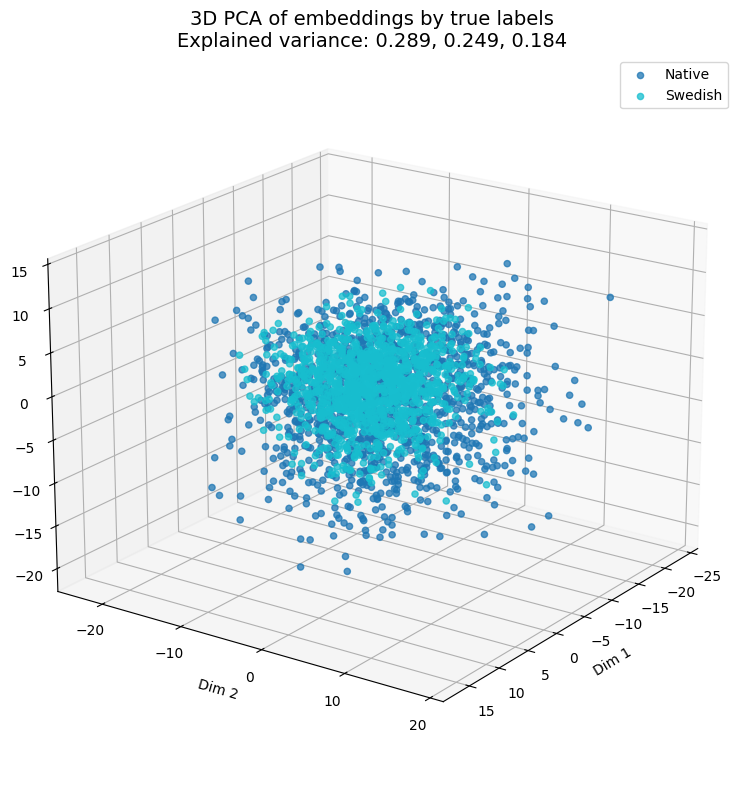

In [16]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x1_n_40ms, y1_n_40ms, class_names=["Native", "Swedish"])

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (2500, 128)


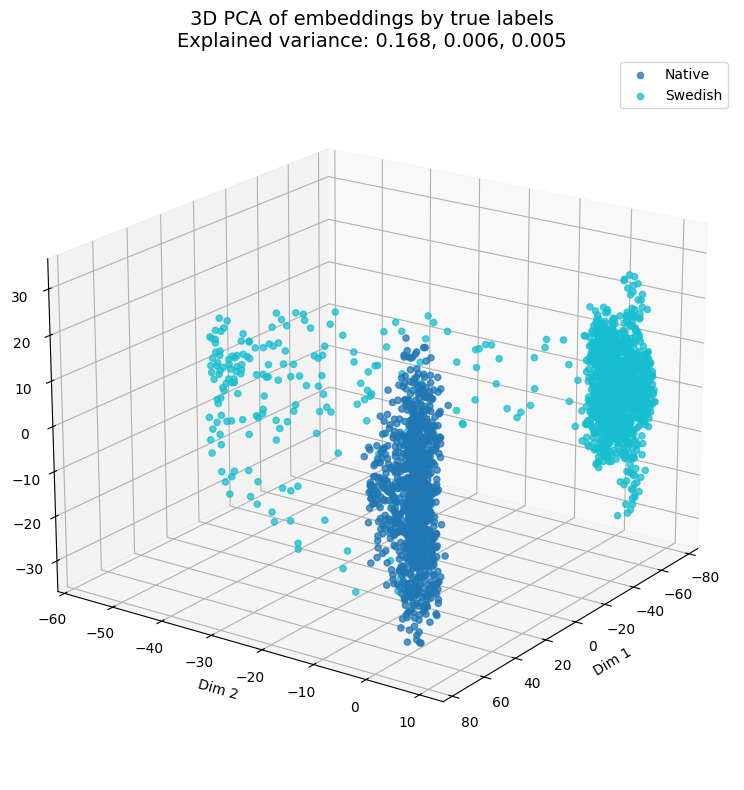

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model4_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x1_n_40ms, y1_n_40ms, class_names=["Native", "Swedish"], K=200)

## 2

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


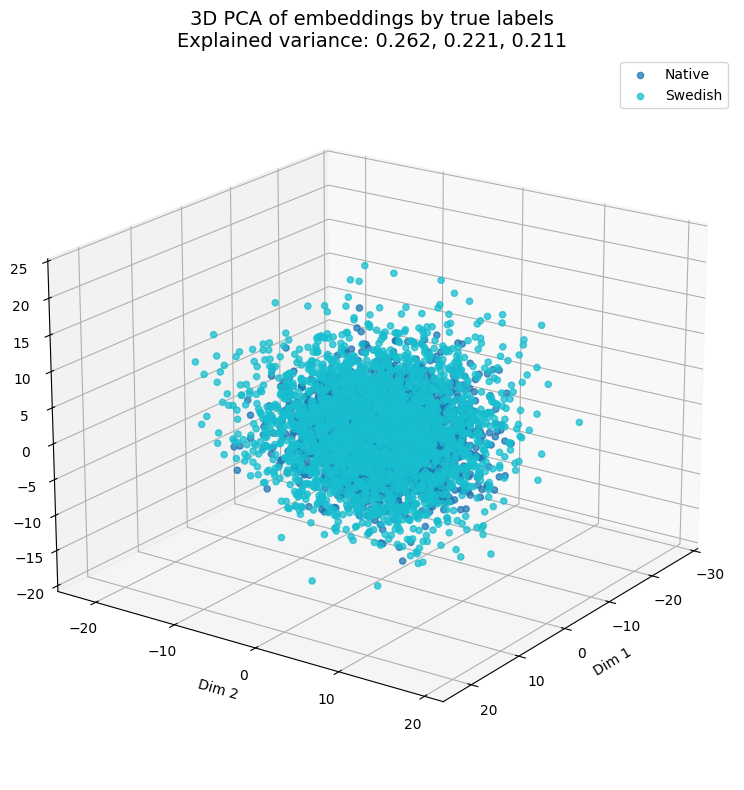

In [15]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x2_n_40ms, y2_n_40ms, class_names=["Native", "Swedish"])

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


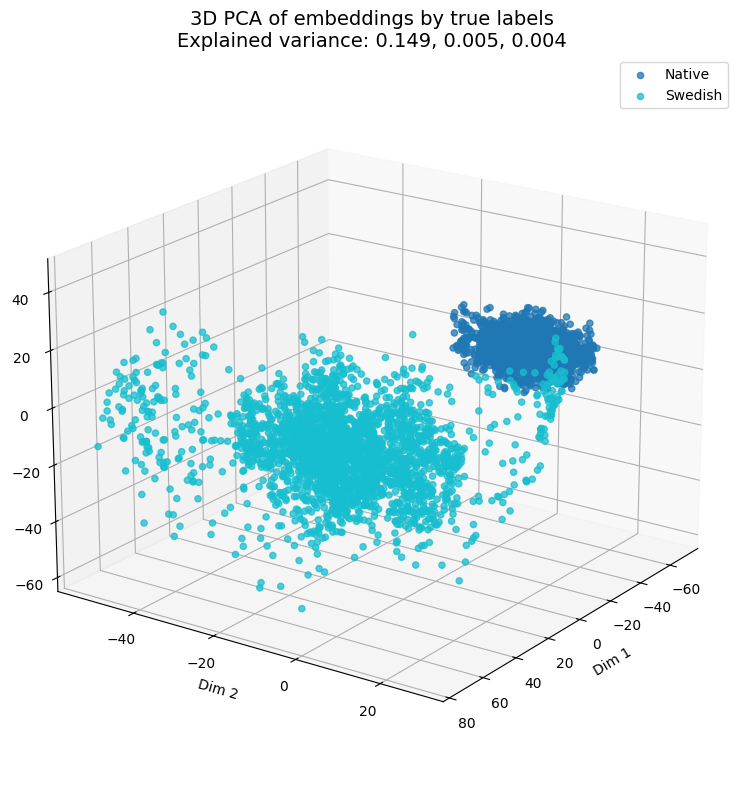

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model5_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x2_n_40ms, y2_n_40ms, class_names=["Native", "Swedish"], K=200)

## 3

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


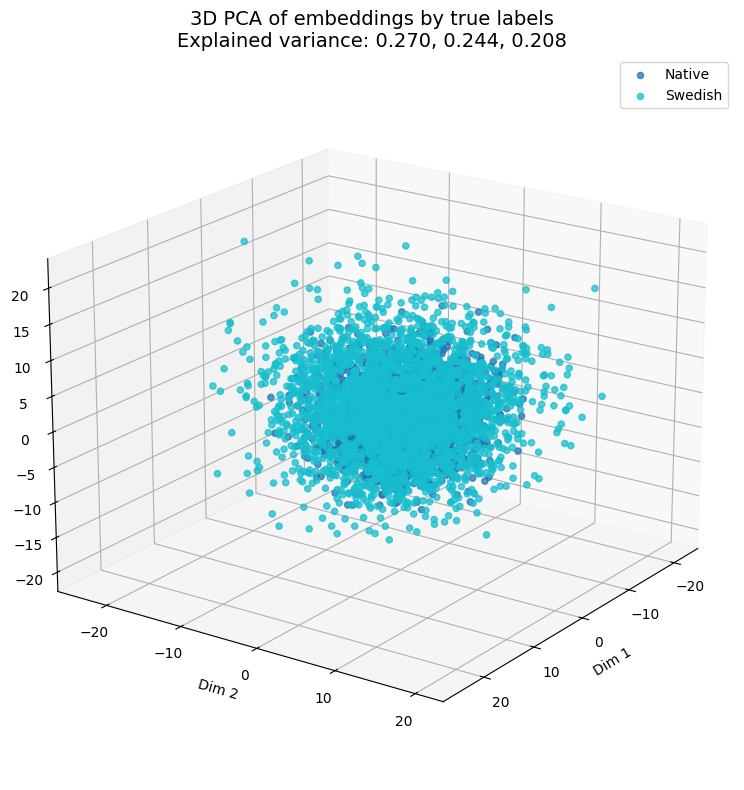

In [17]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x3_n_40ms, y3_n_40ms, class_names=["Native", "Swedish"])

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


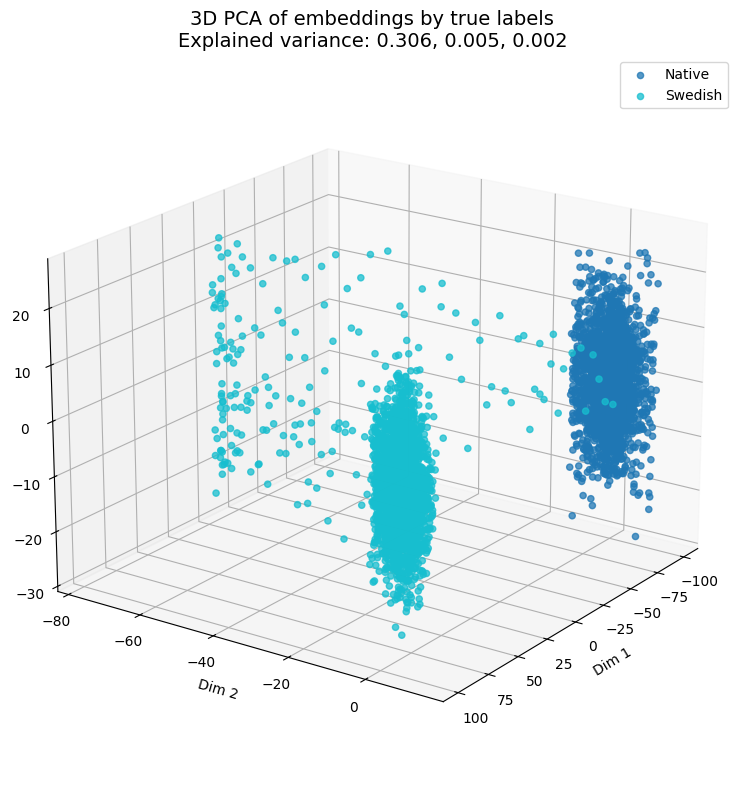

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x3_n_40ms, y3_n_40ms, class_names=["Native", "Swedish"], K=200)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


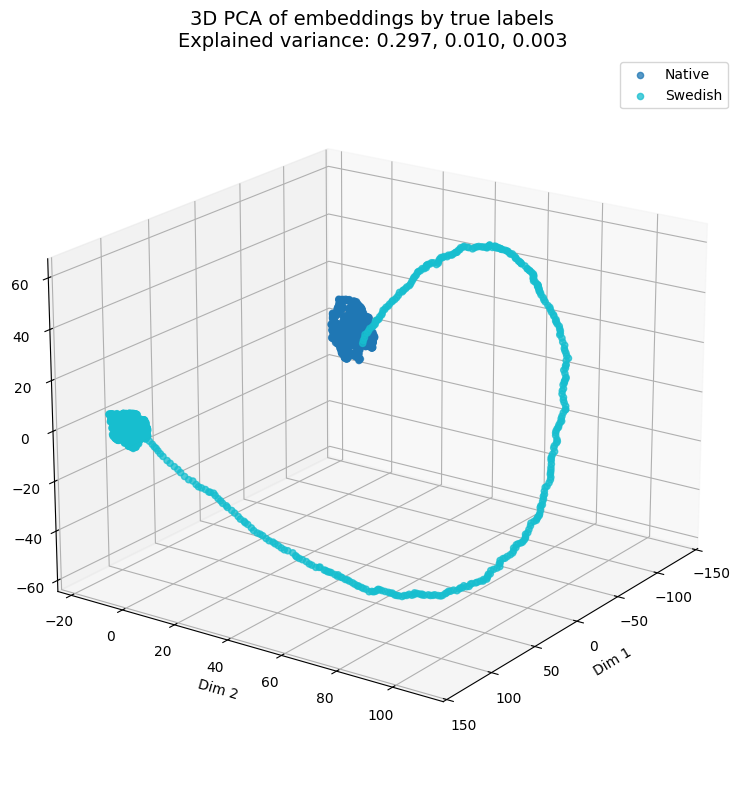

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x3_n_40ms, y3_n_40ms, class_names=["Native", "Swedish"], K=400)

## 4

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


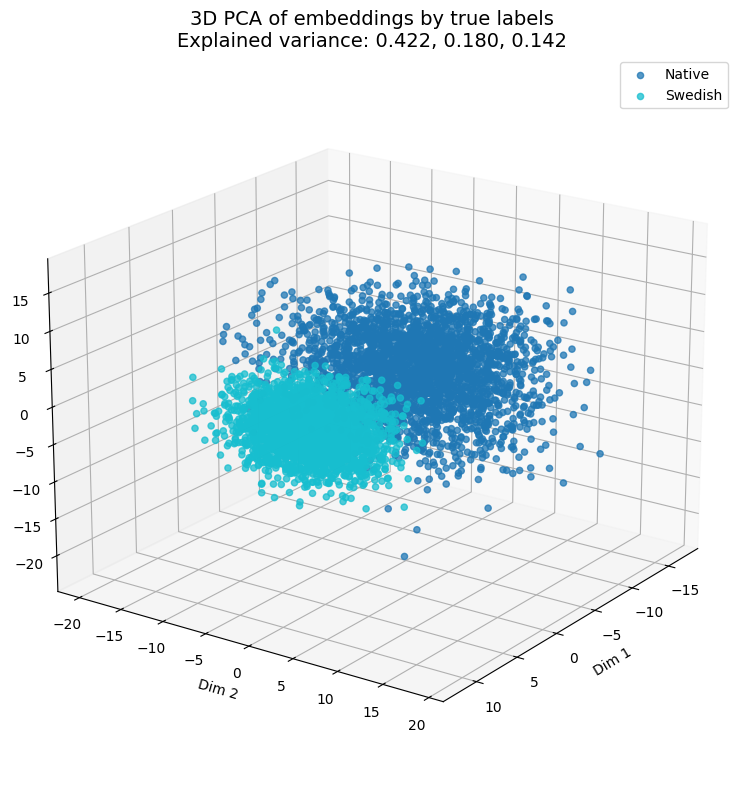

In [18]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x4_n_40ms, y4_n_40ms, class_names=["Native", "Swedish"])

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


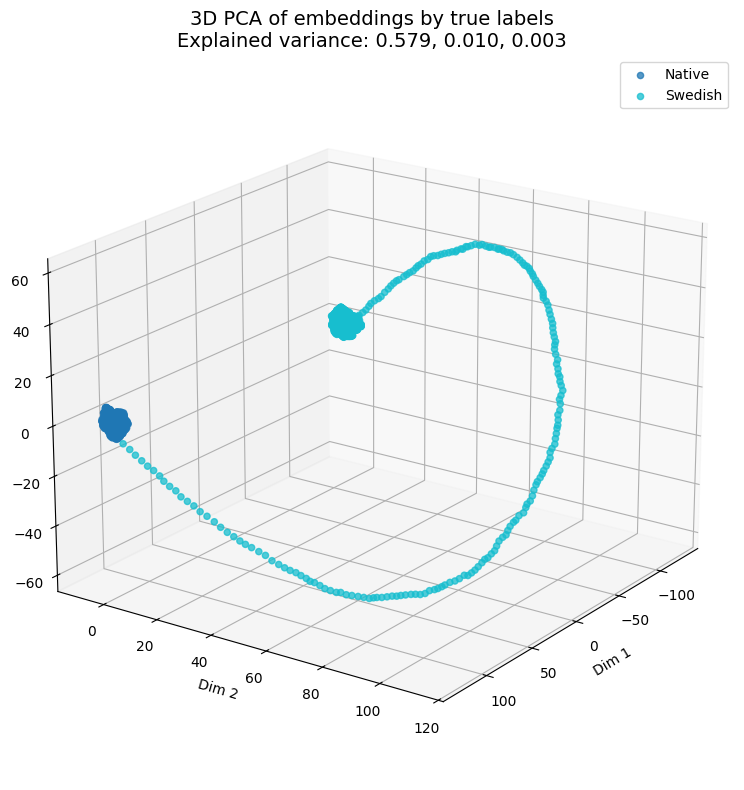

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x4_n_40ms, y4_n_40ms, class_names=["Native", "Swedish"], K=200)

## 5

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


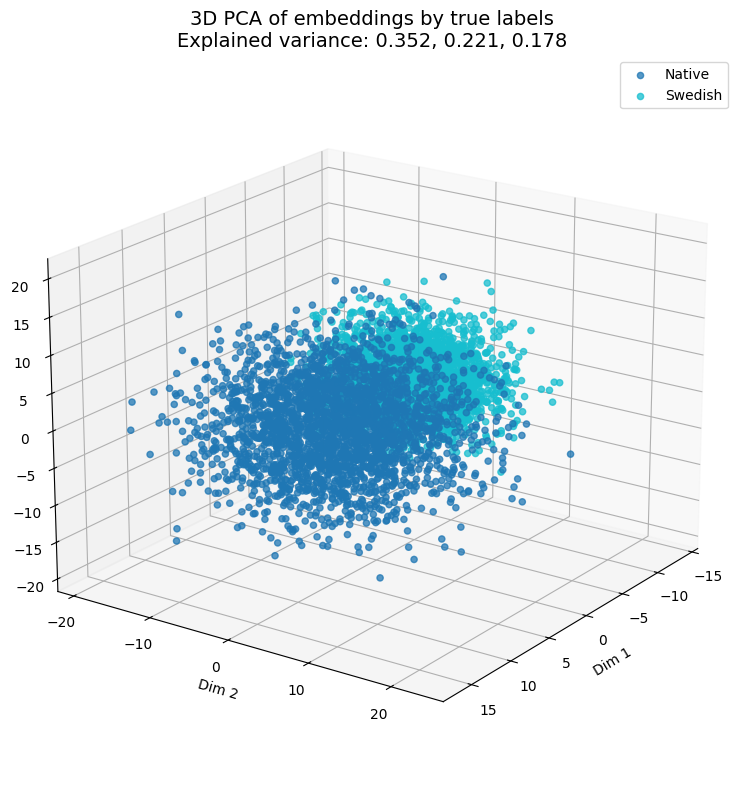

In [19]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x5_n_40ms, y5_n_40ms, class_names=["Native", "Swedish"])

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


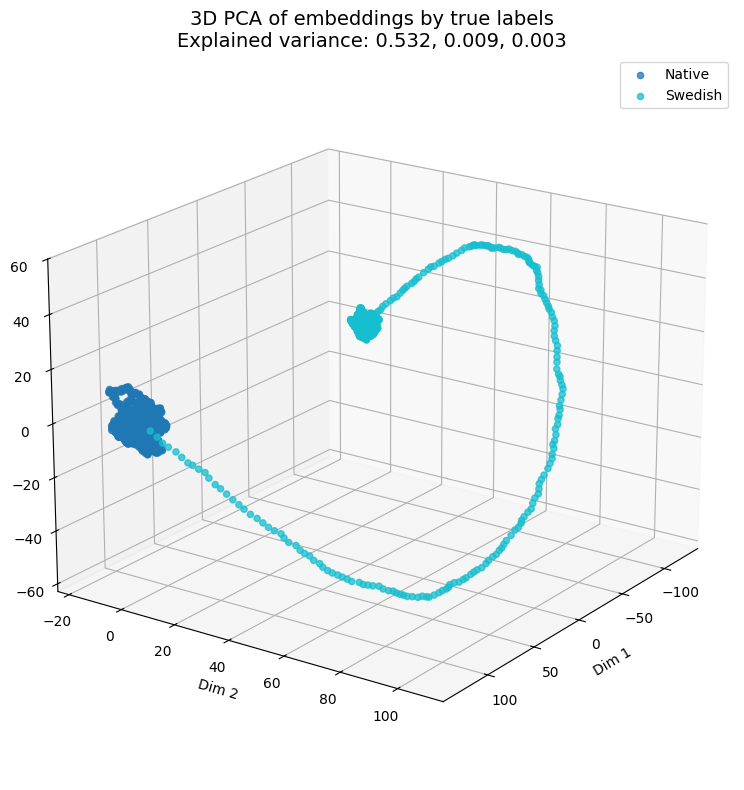

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x5_n_40ms, y5_n_40ms, class_names=["Native", "Swedish"], K=200)

## 6

==> Extracting embeddings (proj_dim) ...
Emb dims: set (10000, 128)
------------ cannot concatenate, returning a copy ------------


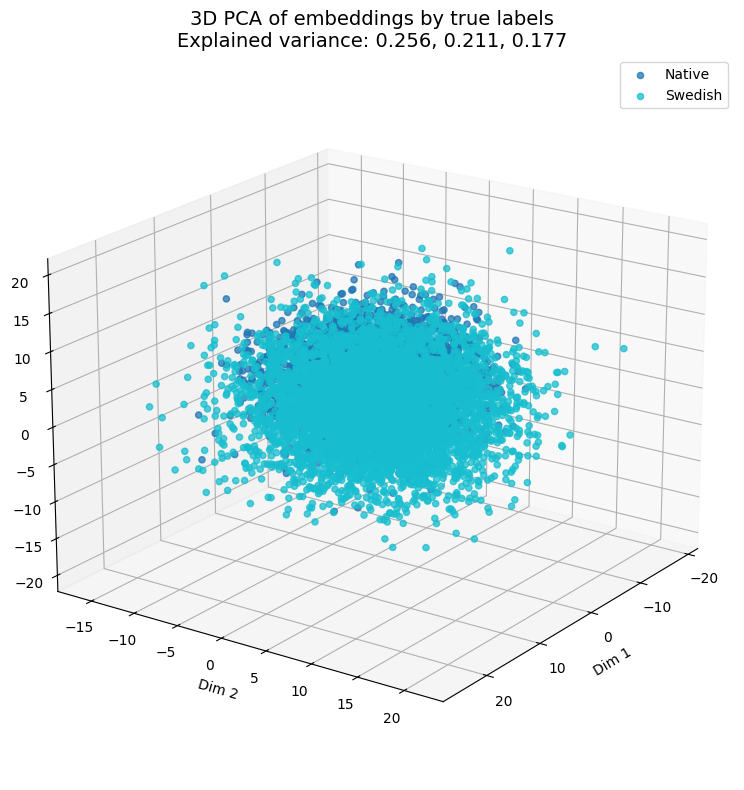

In [20]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x6_n_40ms, y6_n_40ms, class_names=["Native", "Swedish"])

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (10000, 128)


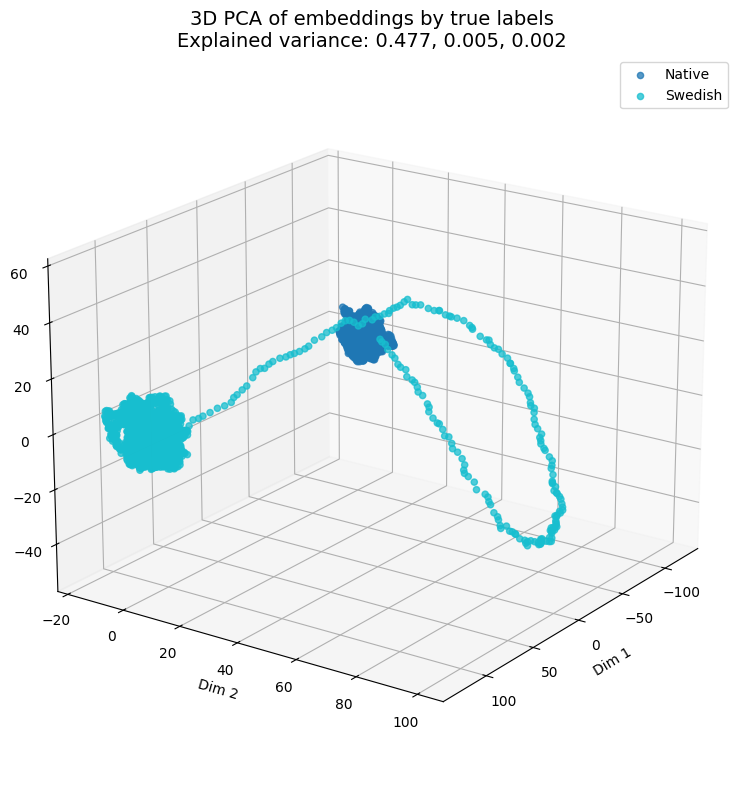

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model2_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x6_n_40ms, y6_n_40ms, class_names=["Native", "Swedish"], K=200)

## 7

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


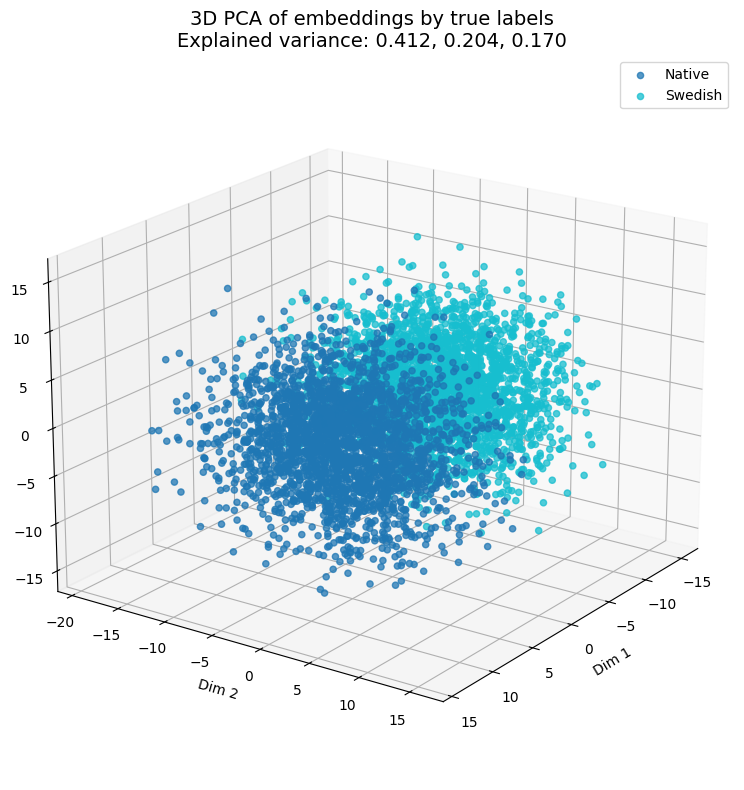

In [21]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x7_n_40ms, y7_n_40ms, class_names=["Native", "Swedish"])

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


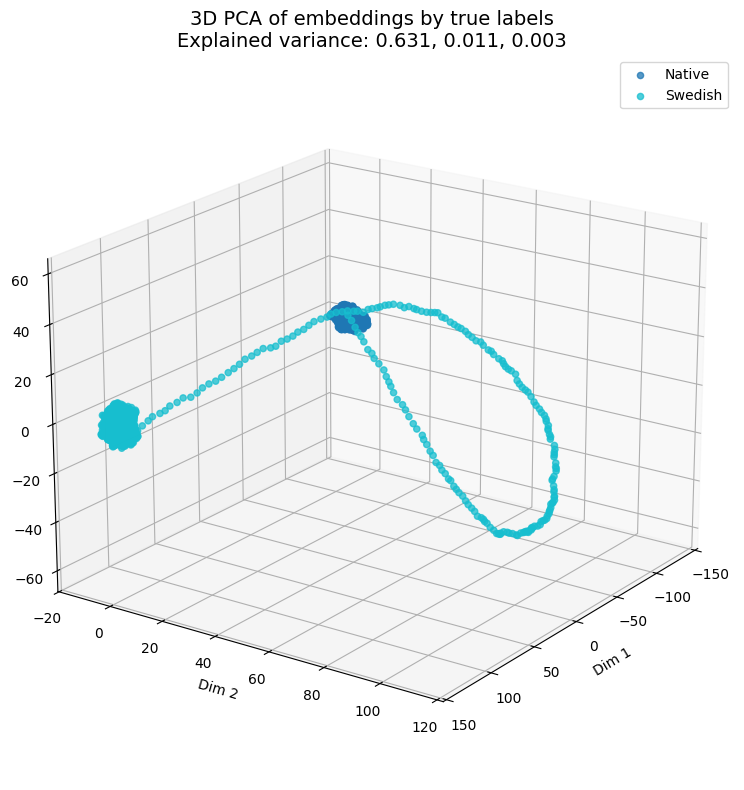

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model8_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x7_n_40ms, y7_n_40ms, class_names=["Native", "Swedish"], K=200)

## 8

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


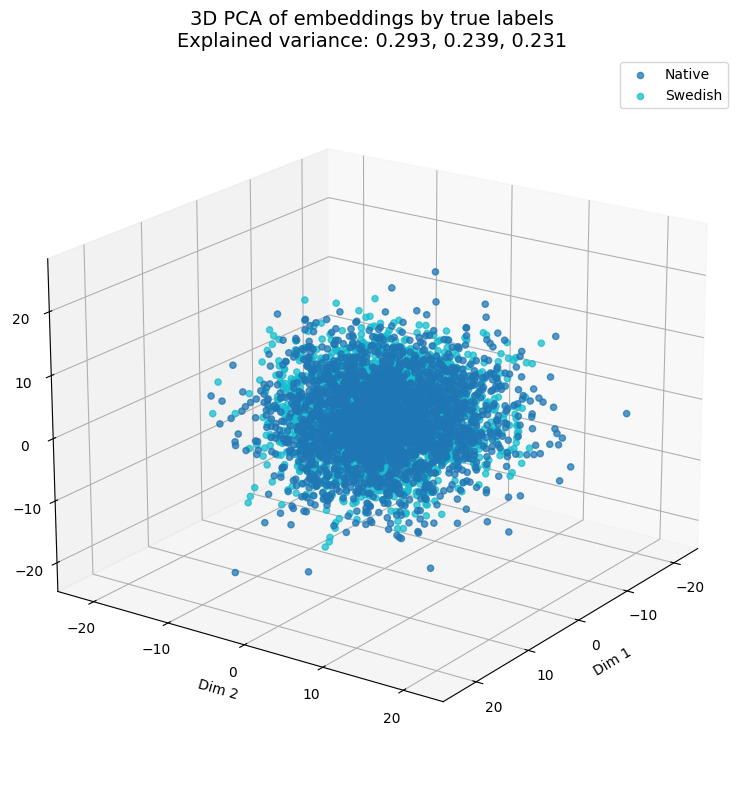

In [22]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model9_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"])

### k = 100

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


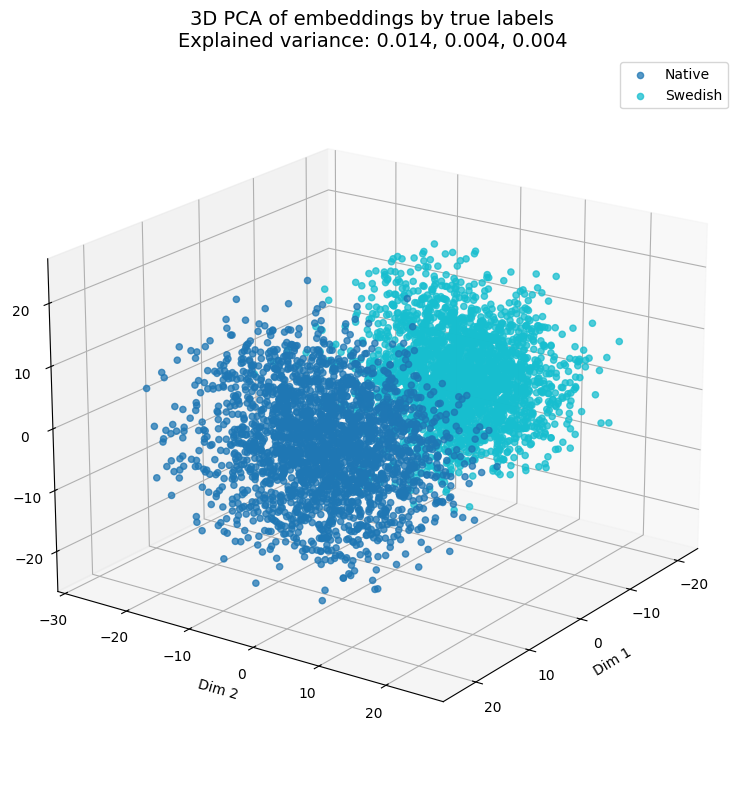

In [23]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=100)

### k = 50

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


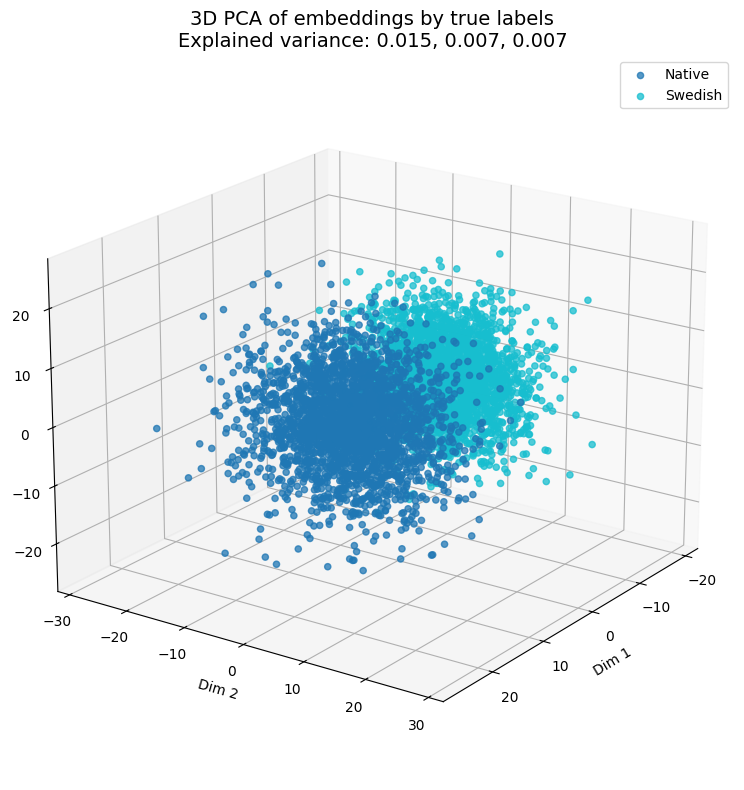

In [24]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=50)

### k = 25

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


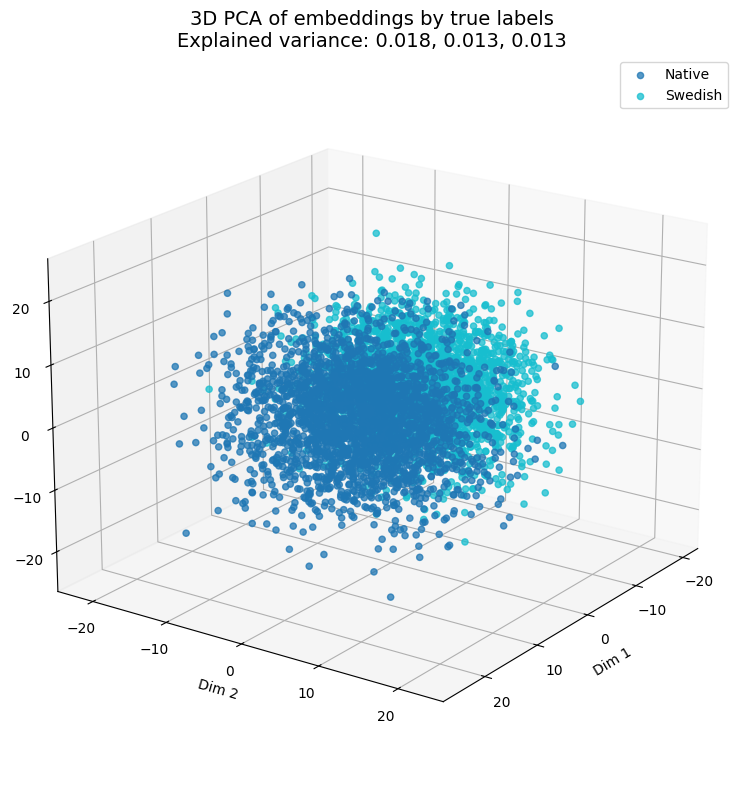

In [25]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=25)

### k = 200

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


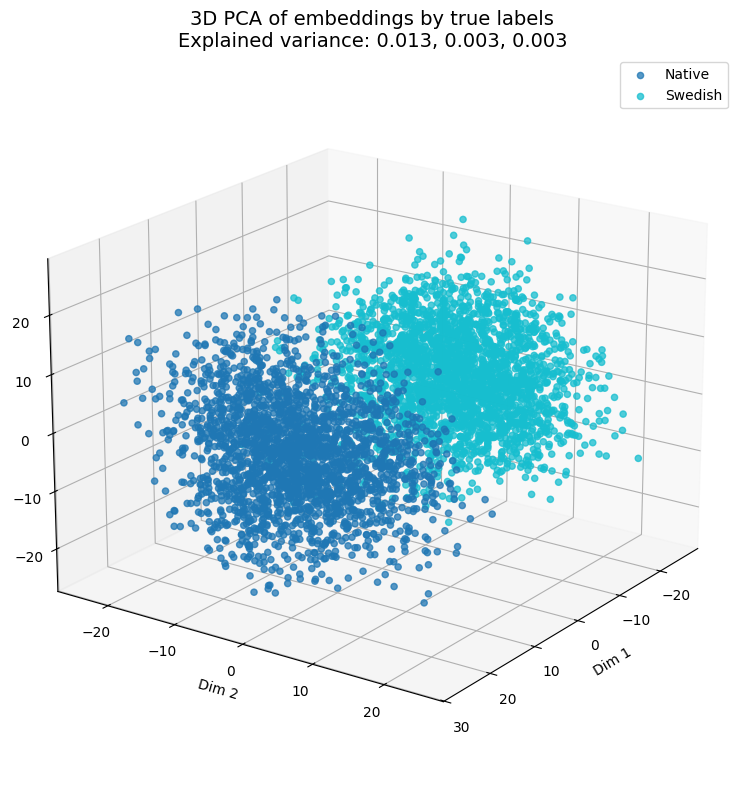

In [27]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=200)

###  k = 400

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


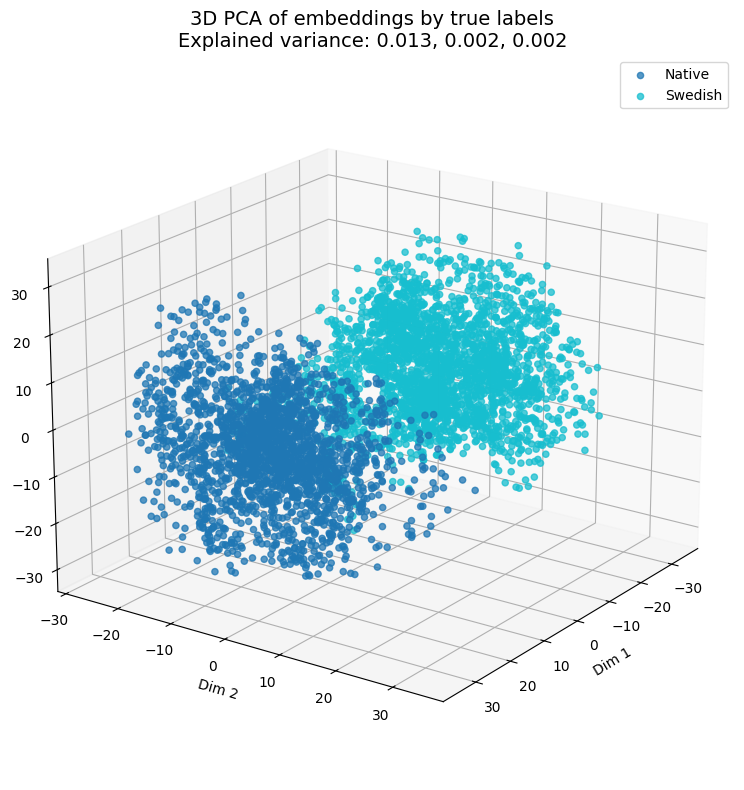

In [28]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=400)

### k=800

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


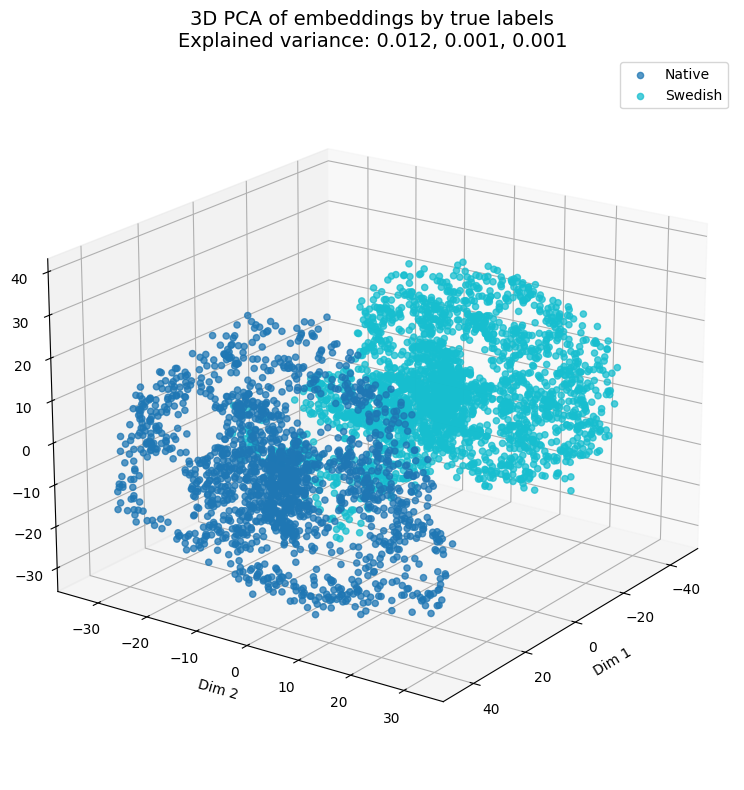

In [30]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=800)

### k=1000

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


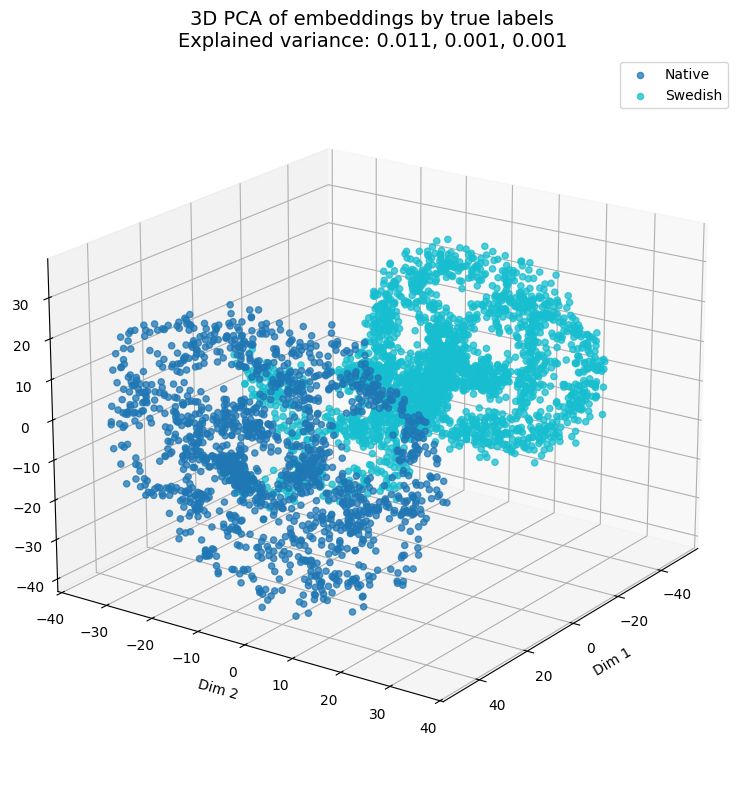

In [31]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=1000)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


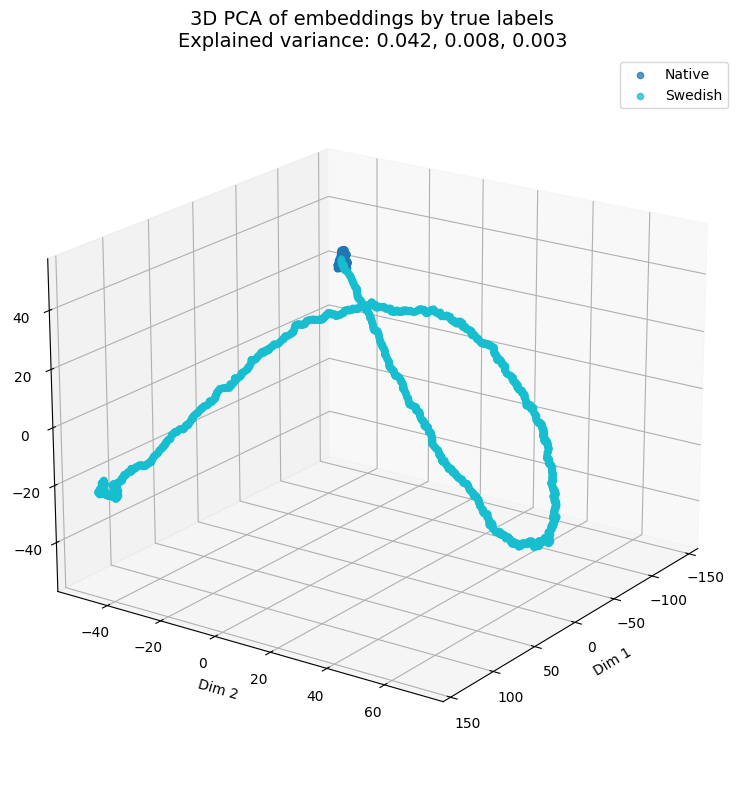

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model9_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x8_n_40ms, y8_n_40ms, class_names=["Native", "Swedish"], K=2000)

## 9

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


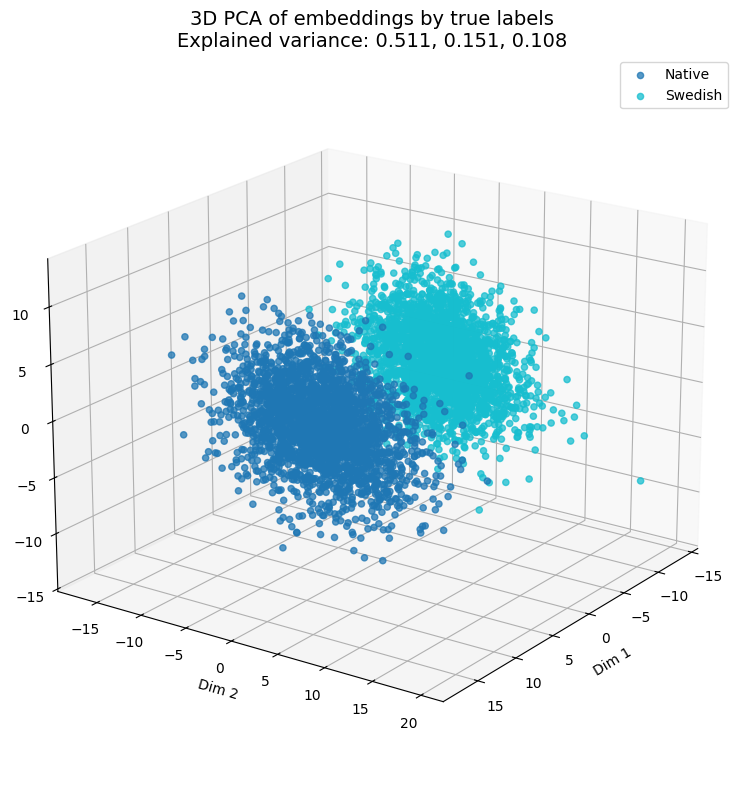

In [32]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x9_n_40ms, y9_n_40ms, class_names=["Native", "Swedish"])

### k = 200

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


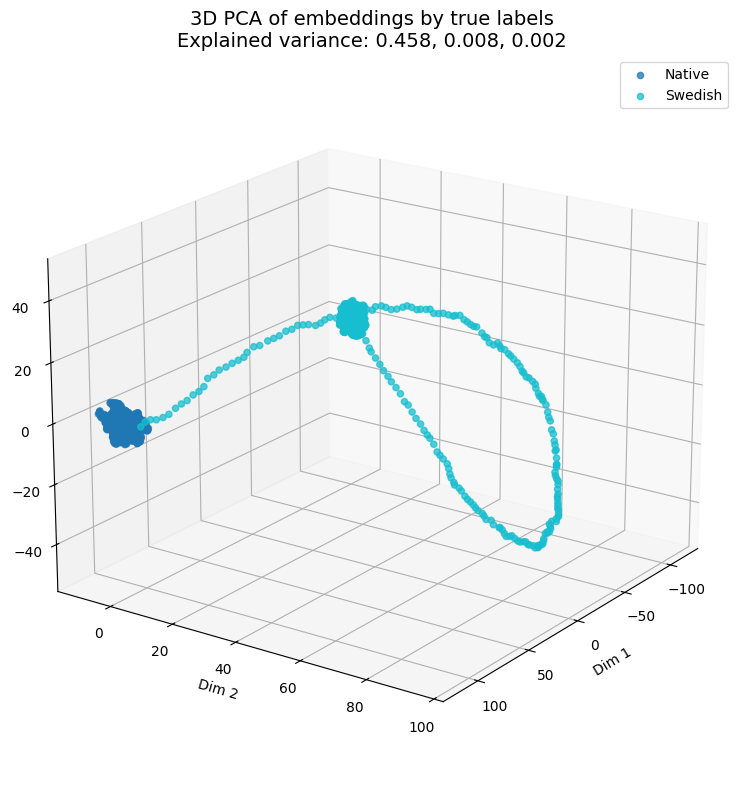

In [47]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x9_n_40ms, y9_n_40ms, class_names=["Native", "Swedish"], K=200)

## 10

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


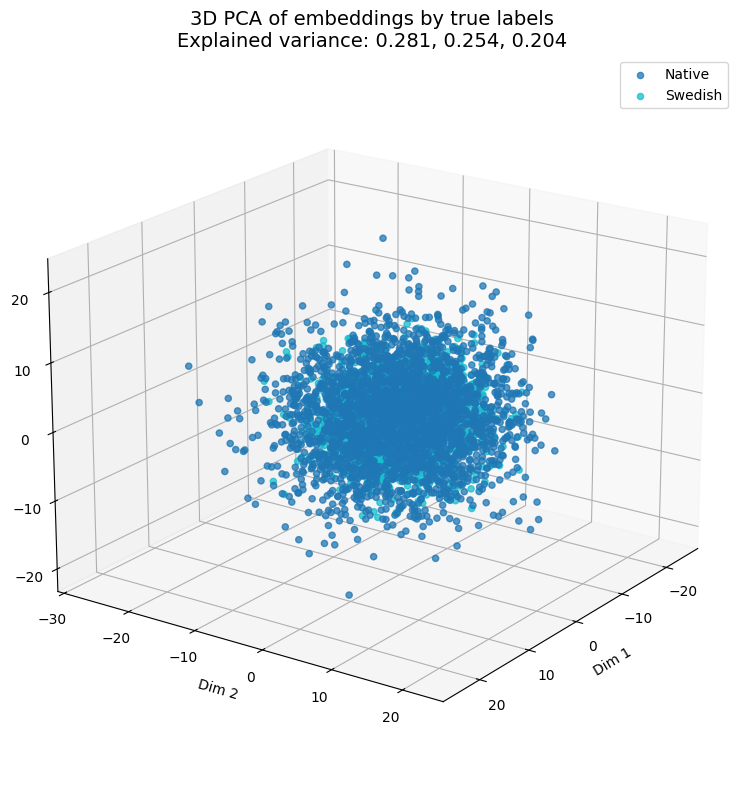

In [33]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x10_n_40ms, y10_n_40ms, class_names=["Native", "Swedish"])

#### k = 25

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


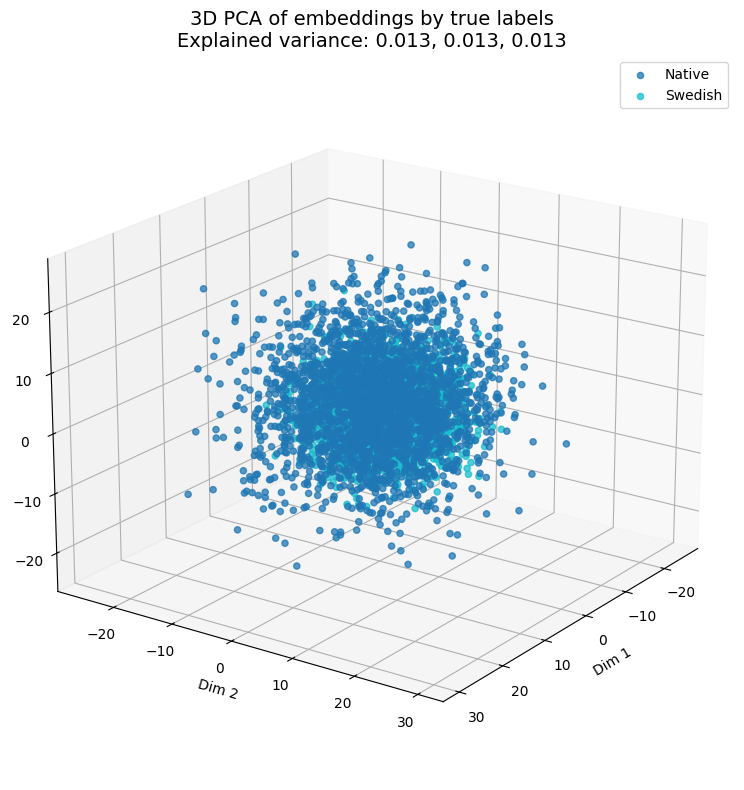

In [45]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x10_n_40ms, y10_n_40ms, class_names=["Native", "Swedish"], K=25)

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


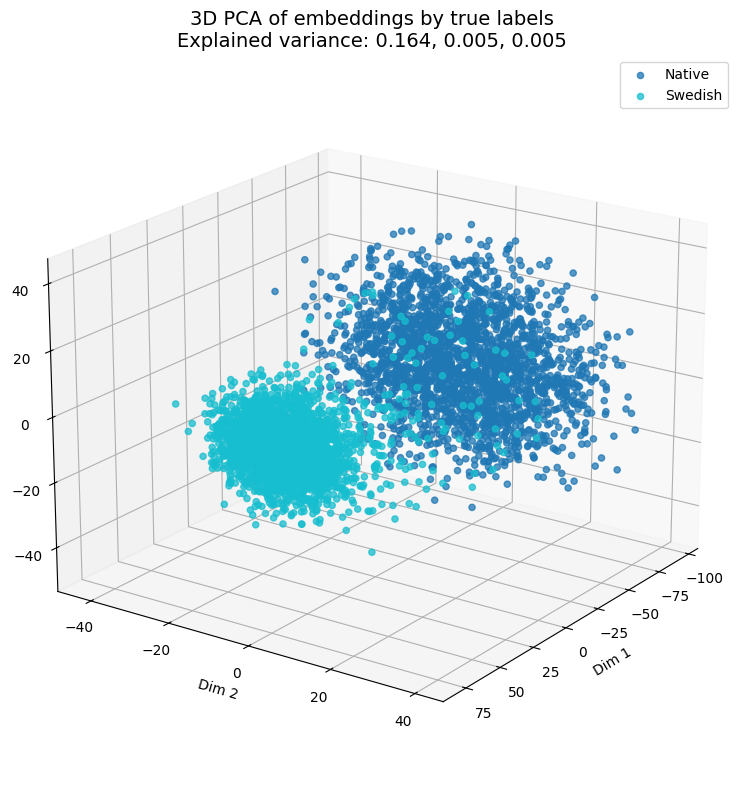

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x10_n_40ms, y10_n_40ms, class_names=["Native", "Swedish"], K=200)

In [ ]:
128*25

3200

## 11

### k=1 => 40ms inputs

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


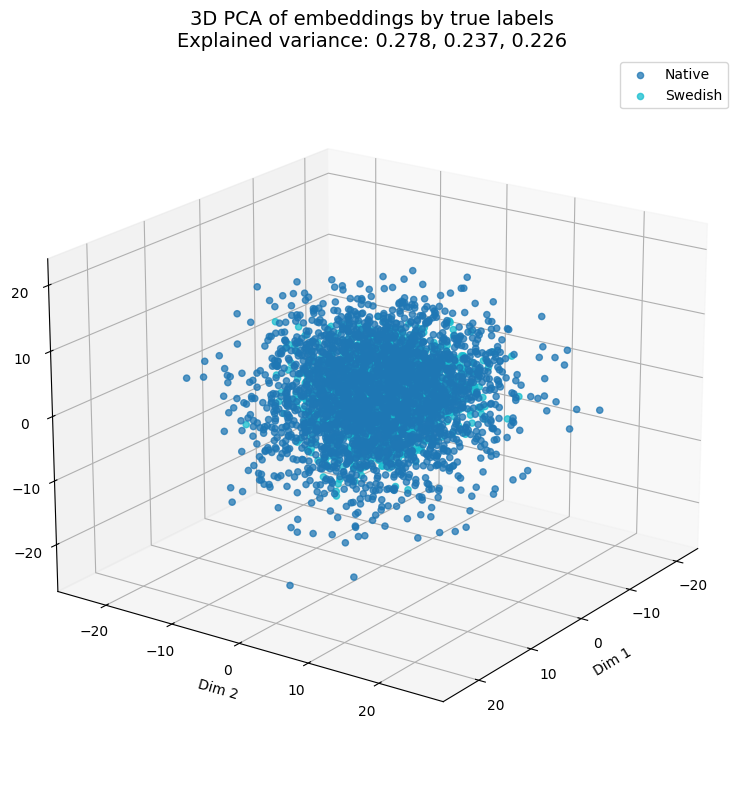

In [43]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x11_n_40ms, y11_n_40ms, class_names=["Native", "Swedish"])

### k = 200

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


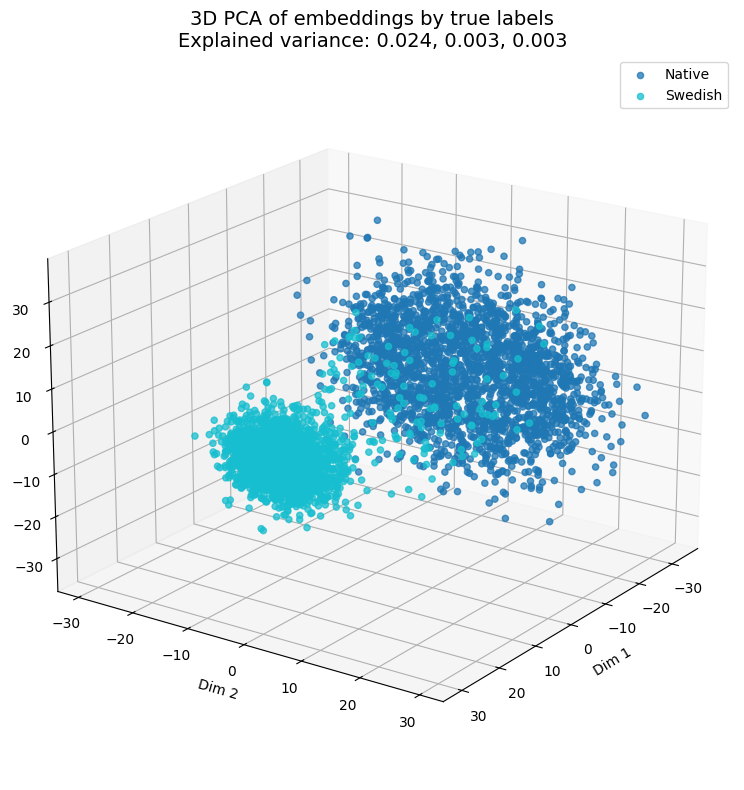

In [44]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x11_n_40ms, y11_n_40ms, class_names=["Native", "Swedish"], K=200)

## 12

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


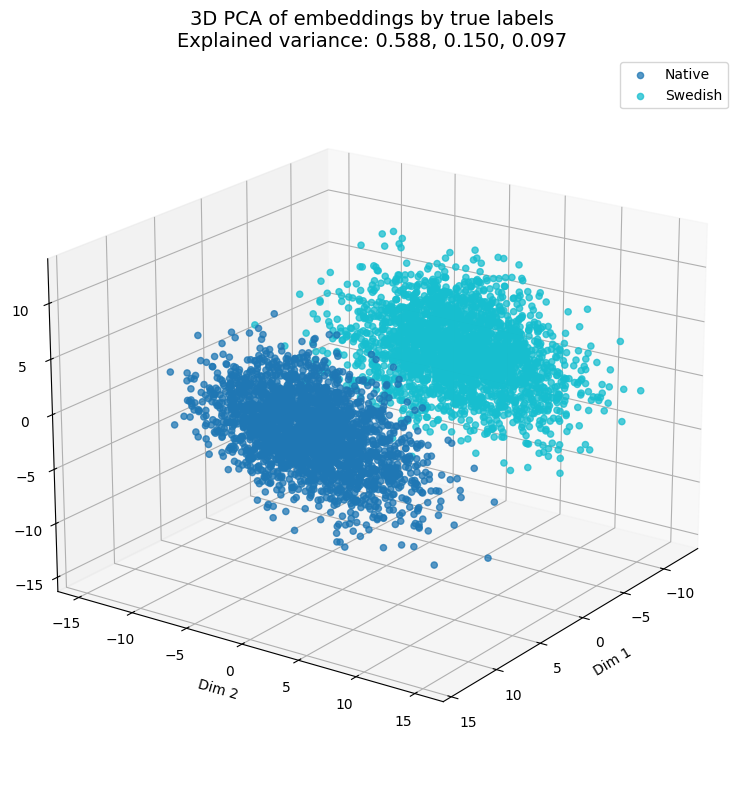

In [39]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x12_n_40ms, y12_n_40ms, class_names=["Native", "Swedish"])

### 1s, k=25

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


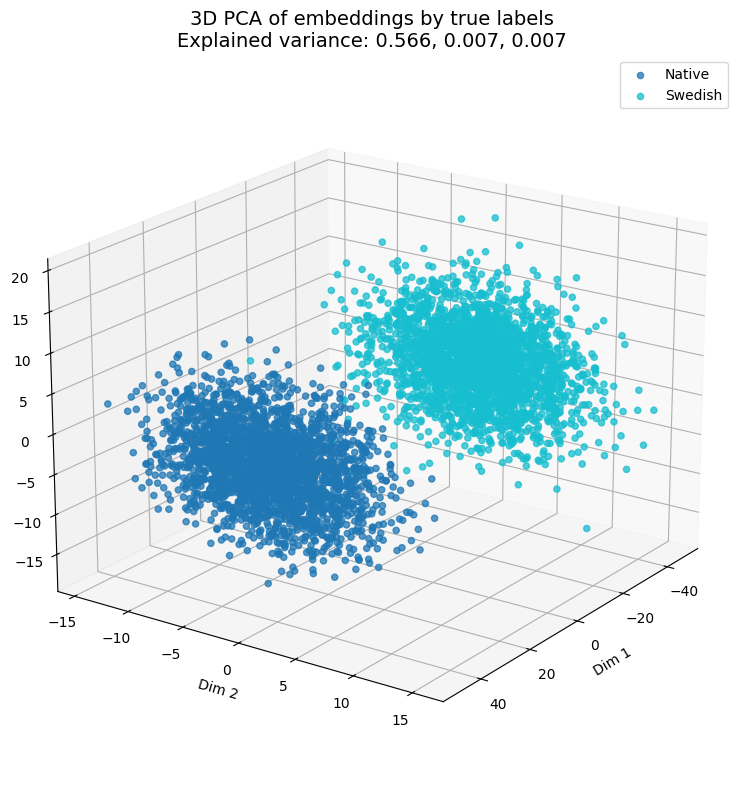

In [40]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x12_n_40ms, y12_n_40ms, class_names=["Native", "Swedish"], K=25)

### k=50

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


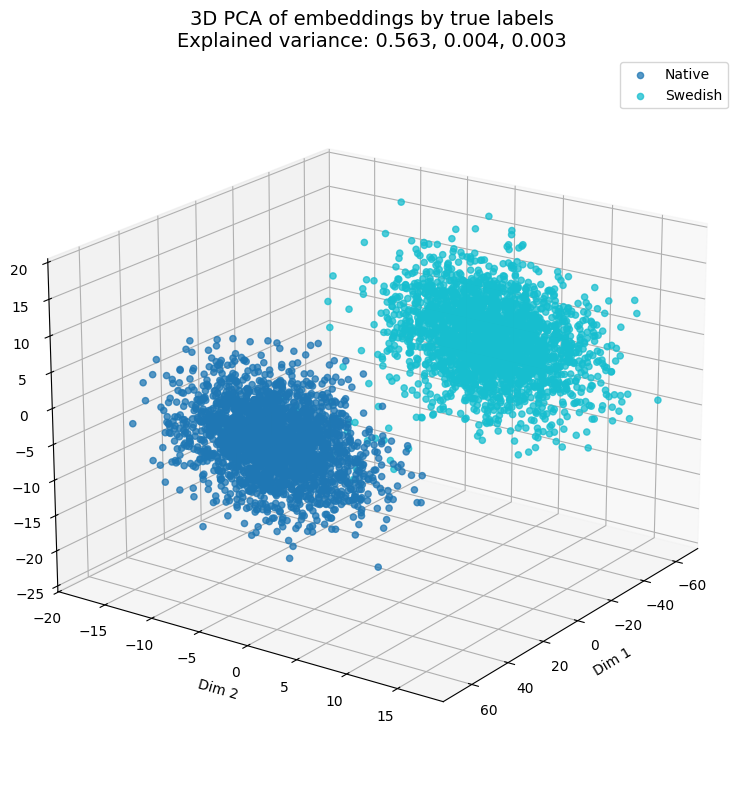

In [41]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x12_n_40ms, y12_n_40ms, class_names=["Native", "Swedish"], K=50)

### K=100

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


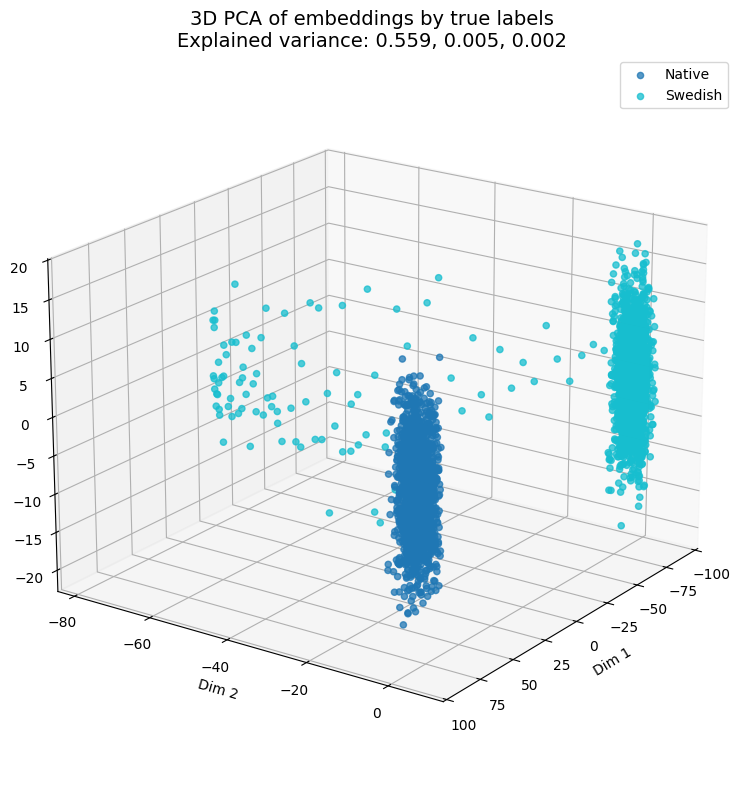

In [42]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x12_n_40ms, y12_n_40ms, class_names=["Native", "Swedish"], K=100)

k=200

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


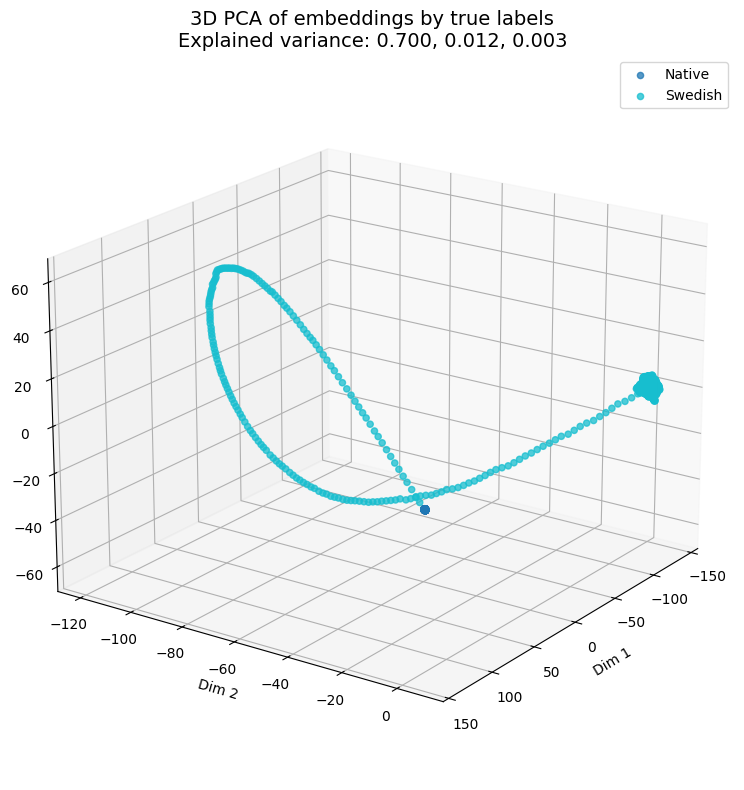

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x12_n_40ms, y12_n_40ms, class_names=["Native", "Swedish"], K=200)

## 13

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)
------------ cannot concatenate, returning a copy ------------


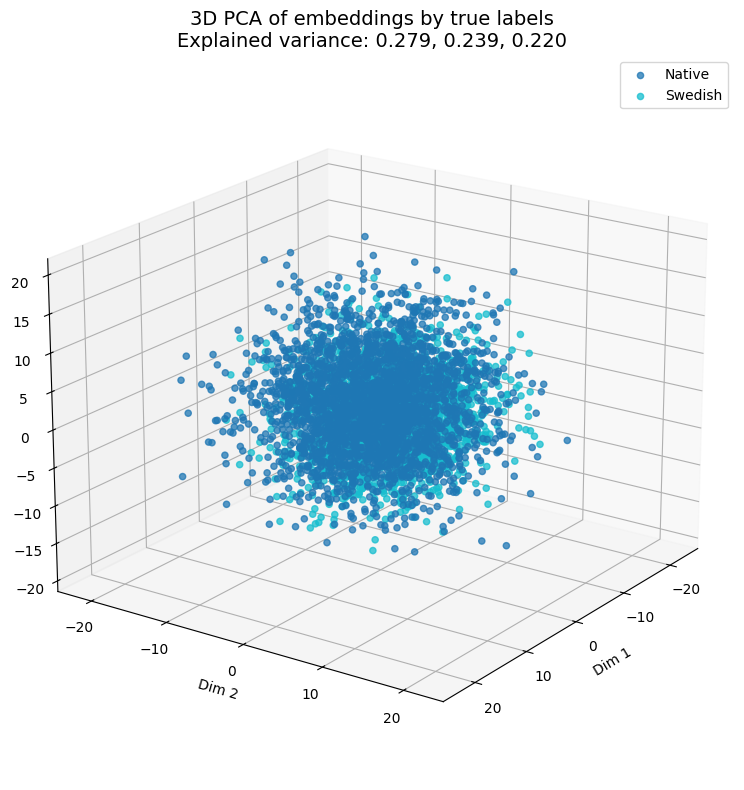

In [37]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x13_n_40ms, y13_n_40ms, class_names=["Native", "Swedish"])

### 1s, k=25

==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


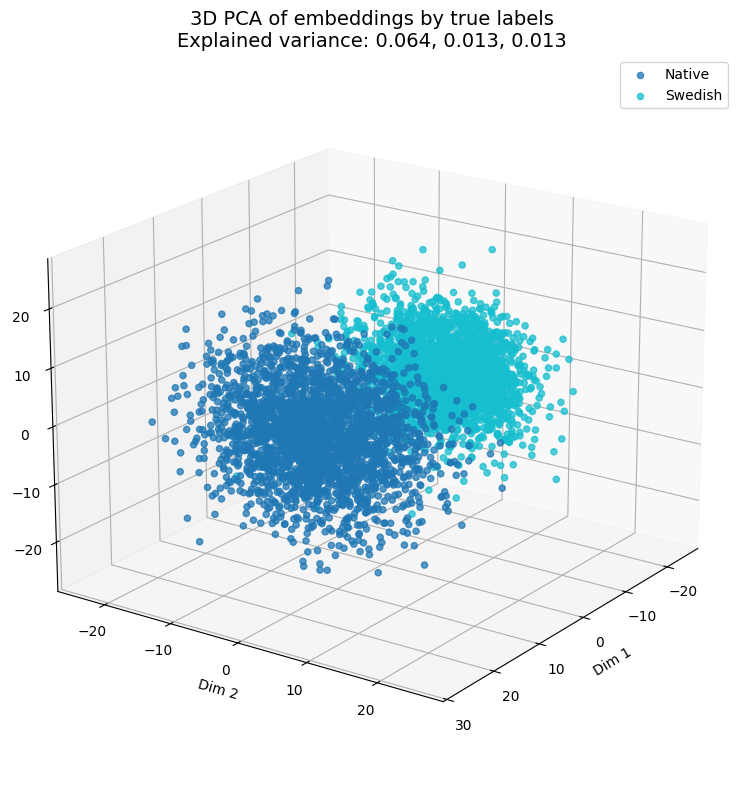

In [38]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x13_n_40ms, y13_n_40ms, class_names=["Native", "Swedish"], K=25)

## 14

==> Extracting embeddings (proj_dim) ...
Emb dims: set (3000, 128)
------------ cannot concatenate, returning a copy ------------


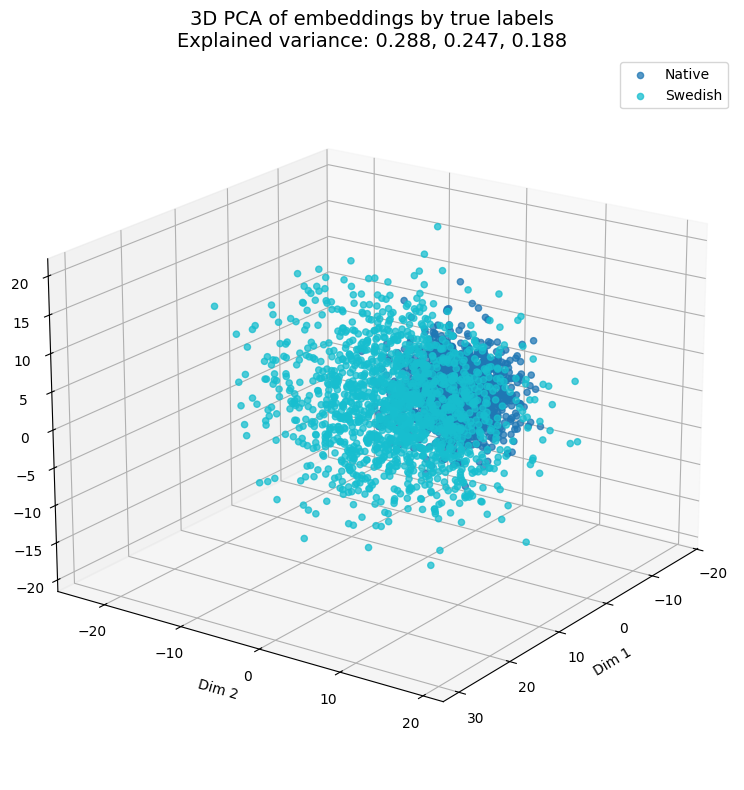

In [36]:
X_pca_3d, pca = create_and_visualize_embeddings_3d_m(rand_encoder, x14_n_40ms, y14_n_40ms, class_names=["Native", "Swedish"])